# Tokenization Papers

In [1]:
import paper_dataset
import pandas as pd
import importlib
import re
import matplotlib.pyplot as plt
importlib.reload(paper_dataset)

<module 'paper_dataset' from '/lnet/work/people/vico/TokSurvey/paper_dataset.py'>

In [2]:
df = paper_dataset.load()

## Samples and RE 

In [ ]:
samples = paper_dataset.sample(df, 5)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: The Geometry of Numerical Reasoning: Language Models Compare Numeric Properties in Linear Subspaces
Author(s): El-Shangiti, Ahmed Oumar and Hiraoka, Tatsuya and AlQuabeh, Hilal and Heinzerling, Benjamin and Inui, Kentaro
Year: 2025
Venue: None (ACL)
Volume: Proceedings of the 2025 Conference of the Nations of the Americas Chapter of the Association for Computational Linguistics: Human Language Technologies (Volume 2: Short Papers)
--------------------------------------------------------------------------------
Abstract:
   This paper investigates whether large language models (LLMs) utilize
   numerical attributes encoded in a low-dimensional subspace of
   theembedding space when answering questions involving numeric
   comparisons, e.g., Was Cristiano born before Messi? We first
   identified,using partial least squares regression, these subspaces,
   which effectively encode the numerical attributes associated with the
   entities in comparison prompts. Further, we demonstrat

In [10]:
recent = df[df['year'] >= 2016]
keywords = re.compile(r"token|sub-?word|segment")
tokenization = recent[recent["abstract"].apply(lambda x: x is not None and re.search(keywords, x.lower()) is not None)]

print(f"Number of papers in the dataset: {len(df)}")
print(f"Number of papers since 2016: {len(recent)}")
print(f"Number of papers on tokenization since 2016: {len(tokenization)}")

Number of papers in the dataset: 149355
Number of papers since 2016: 101891
Number of papers on tokenization since 2016: 8266


In [ ]:
samples = paper_dataset.sample(tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: Spike-driven Transformer V2: Meta Spiking Neural Network Architecture Inspiring the Design of Next-generation Neuromorphic Chips
Author(s): Man Yao and JiaKui Hu and Tianxiang Hu and Yifan Xu and Zhaokun Zhou and Yonghong Tian and Bo XU and Guoqi Li
Year: 2024
Venue: ICLR 2024 poster (ICLR)
Volume: The Twelfth International Conference on Learning Representations
--------------------------------------------------------------------------------
Abstract:
   Neuromorphic computing, which exploits Spiking Neural Networks (SNNs) on
   neuromorphic chips, is a promising energy-efficient alternative to
   traditional AI. CNN-based SNNs are the current mainstream of
   neuromorphic computing. By contrast, no neuromorphic chips are designed
   especially for Transformer-based SNNs, which have just emerged, and
   their performance is only on par with CNN-based SNNs, offering no
   distinct advantage. In this work, we propose a general Transformer-based
   SNN architecture, termed as ``Met

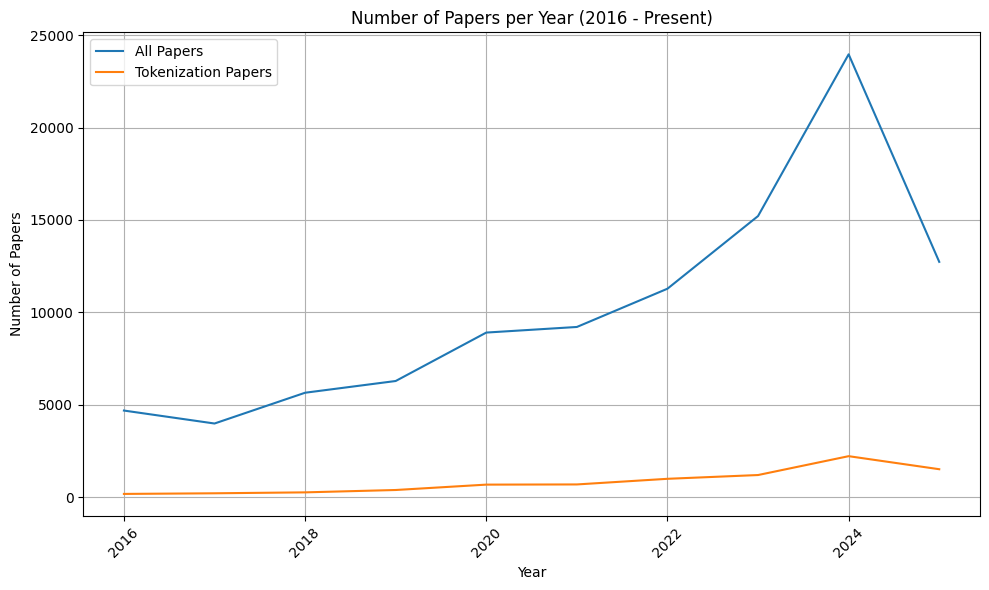

In [6]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line")
tokenization_counts = tokenization['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line")
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Filter with LLM and save the results

In [13]:
import tqdm
import llm_filter
tqdm.tqdm.pandas()

In [ ]:
# if 'topic' not in tokenization.columns:    
#     tokenization['topic'] = tokenization.progress_apply(lambda x: llm_filter.filter_topic(x['title'], x['abstract']), axis=1)
# # Merge the tokenization DataFrame with the original DataFrame adding the column 'topic' (bool)
# df = df.merge(tokenization[['bibtex_id', 'topic']], on='bibtex_id', how='left')
# # Save df to jsonl file
# df.to_json('data/tokenization_papers.jsonl', orient='records', lines=True)

100%|██████████| 8266/8266 [6:19:02<00:00,  2.75s/it]   
/tmp/ipykernel_680737/2315756202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokenization['topic'] = tokenization.progress_apply(lambda x: llm_filter.filter_topic(x['title'], x['abstract']), axis=1)


In [11]:
df = paper_dataset.load('data/tokenization_papers.jsonl')
recent = df[df['year'] >= 2016]
real_tokenization = df[df['topic'] == True]

In [ ]:

samples = paper_dataset.sample(real_tokenization, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

Title: Compact Speech Translation Models via Discrete Speech Units Pretraining
Author(s): Lam, Tsz Kin and Birch, Alexandra and Haddow, Barry
Year: 2024
Venue: IWSLT (ACL)
Volume: Proceedings of the 21st International Conference on Spoken Language Translation (IWSLT 2024)
--------------------------------------------------------------------------------
Abstract:
   We propose a pretraining method to use Self-Supervised Speech (SSS)
   model to creating more compact Speech-to-text Translation. In contrast
   to using the SSS model for initialization, our method is more suitable
   to memory constrained scenario such as on-device deployment. Our method
   is based on Discrete Speech Units (DSU) extracted from the SSS model. In
   the first step, our method pretrains two smaller encoder-decoder models
   on 1) Filterbank-to-DSU (Fbk-to-DSU) and 2) DSU-to-Translation (DSU-to-
   Trl) data respectively. The DSU thus become the distillation inputs of
   the smaller models. Subsequently, the e

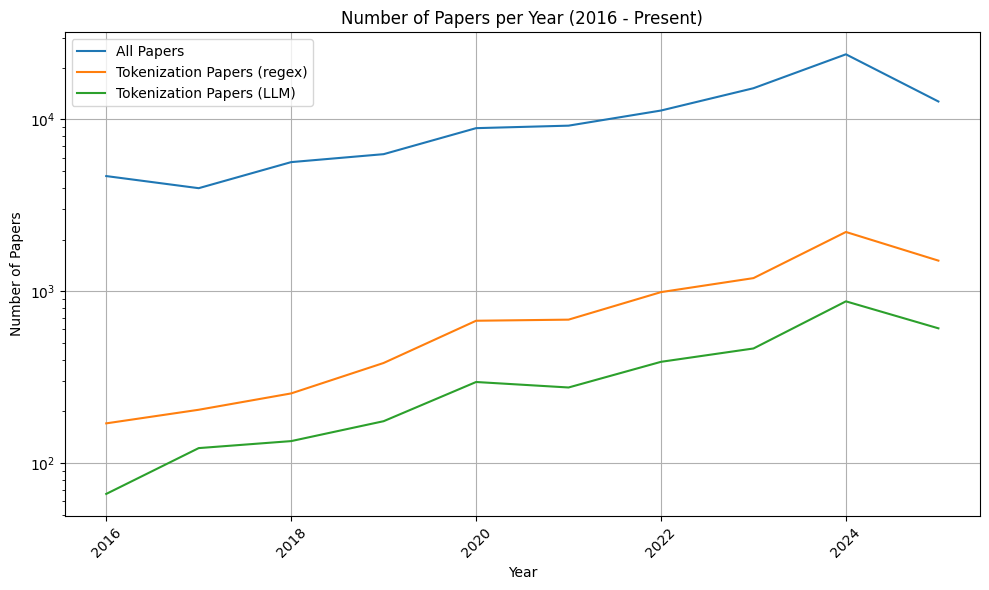

In [12]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
recent_counts.plot(kind="line", logy=True)
tokenization_counts = tokenization['year'].value_counts().sort_index()
tokenization_counts.plot(kind="line", logy=True)
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
real_tokenization_counts.plot(kind="line", logy=True)
plt.title('Number of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['All Papers', 'Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

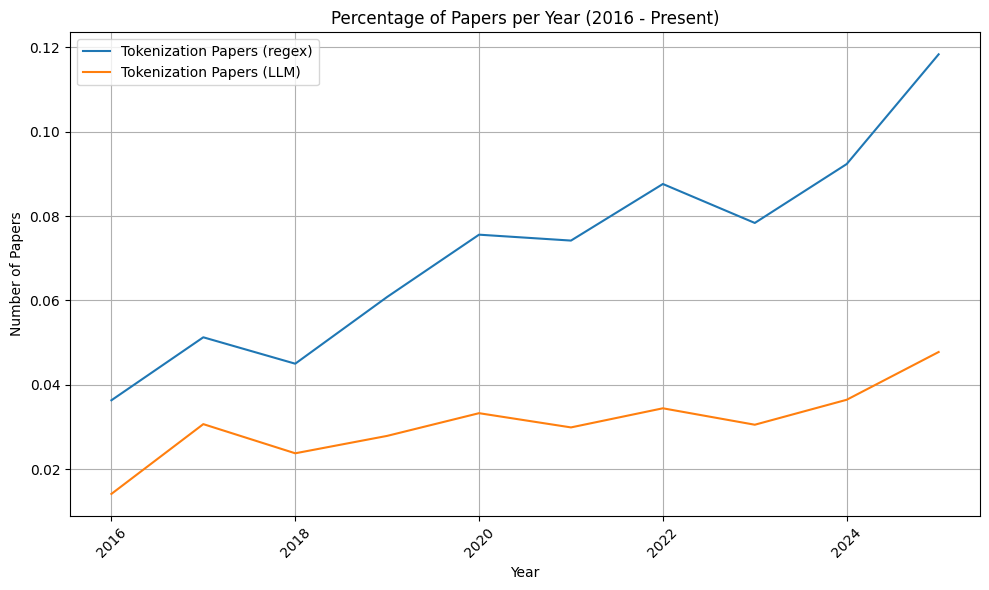

In [13]:
# Plot the number of papers per year
plt.figure(figsize=(10, 6))
recent_counts = recent['year'].value_counts().sort_index()
tokenization_counts = tokenization['year'].value_counts().sort_index()
(tokenization_counts / recent_counts).plot(kind="line")
real_tokenization_counts = real_tokenization['year'].value_counts().sort_index()
(real_tokenization_counts / recent_counts).plot(kind="line")
plt.title('Percentage of Papers per Year (2016 - Present)')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend(['Tokenization Papers (regex)', 'Tokenization Papers (LLM)'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Type of the paper
- Tokeniser/Evaluation/Application/Other

In [21]:
import tqdm
tqdm.tqdm.pandas()
import llm_filter
importlib.reload(llm_filter)

<module 'llm_filter' from '/lnet/work/people/vico/TokSurvey/llm_filter.py'>

In [3]:
df = paper_dataset.load('data/tokenization_papers.jsonl')
real_tokenization = df[df['topic'] == True]
# real_tokenization

In [19]:
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_tokeniser(a, t), 'tokenization')
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_evaluation(a, t), 'evaluation')
llm_filter.test('test_set.json', lambda a, t, c: llm_filter.is_survey(a, t), 'survey')

100%|██████████| 9/9 [05:05<00:00, 33.99s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: True (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: False)


100%|██████████| 9/9 [05:03<00:00, 33.77s/it]


Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: True (Reference: True)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: True (Reference: Tru

100%|██████████| 9/9 [05:06<00:00, 34.11s/it]

Title: ADASPLASH: Adaptive Sparse Flash Attention
Answer: False (Reference: None)
--------------------------------------------------------------------------------
Title: Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: LANGUAGE MODELLING WITH PIXELS
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Dynamic Chunking for End-to-End Hierarchical Sequence Modeling
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Tokenization and the Noiseless Channel
Answer: False (Reference: False)
--------------------------------------------------------------------------------
Title: Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models
Answer: False (Reference: 

In [22]:
if 'tokenization' not in real_tokenization.columns:    
    real_tokenization['tokenization'] = real_tokenization.progress_apply(lambda x: llm_filter.is_tokeniser(x['title'], x['abstract']), axis=1)
if 'evaluation' not in real_tokenization.columns:    
    real_tokenization['evaluation'] = real_tokenization.progress_apply(lambda x: llm_filter.is_evaluation(x['title'], x['abstract']), axis=1)
if 'survey' not in real_tokenization.columns:
    real_tokenization['survey'] = real_tokenization.progress_apply(lambda x: llm_filter.is_survey(x['title'], x['abstract']), axis=1)
if 'application' not in real_tokenization.columns:
    real_tokenization['application'] = ~(real_tokenization['tokenization'] | real_tokenization['evaluation'] | real_tokenization['survey'])

  0%|          | 0/3401 [00:00<?, ?it/s]100%|██████████| 3401/3401 [13:21:04<00:00, 14.13s/it]  
/tmp/ipykernel_995543/318793232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_tokenization['tokenization'] = real_tokenization.progress_apply(lambda x: llm_filter.is_tokeniser(x['title'], x['abstract']), axis=1)
100%|██████████| 3401/3401 [13:01:03<00:00, 13.78s/it]  
/tmp/ipykernel_995543/318793232.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_tokenization['evaluation'] = real_tokenization

100%|██████████| 3401/3401 [13:21:04<00:00, 14.13s/it]  
/tmp/ipykernel_995543/318793232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_tokenization['tokenization'] = real_tokenization.progress_apply(lambda x: llm_filter.is_tokeniser(x['title'], x['abstract']), axis=1)
100%|██████████| 3401/3401 [13:01:03<00:00, 13.78s/it]  
/tmp/ipykernel_995543/318793232.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_tokenization['evaluation'] = real_tokenization.progress_apply(lambda x: llm_filter.is_

In [ ]:
df = df.merge(real_tokenization[['bibtex_id', 'tokenization', 'evaluation', 'application', 'survey']], on='bibtex_id', how='left')
df.to_json('data/tokenization_papers_with_category.jsonl', orient='records', lines=True)

In [39]:
print("§" * 60)
print("TOKENIZATION")
print("§" * 60)

tmp = df[df['tokenization'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

print("§" * 60)
print("EVALUATION")
print("§" * 60)

tmp = df[df['evaluation'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

print("§" * 60)
print("APPLICATION")
print("§" * 60)

tmp = df[df['application'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)

print("§" * 60)
print("SURVEY")
print("§" * 60)

tmp = df[df['survey'] == True]
samples = paper_dataset.sample(tmp, 3)
for s in samples.iloc:
    paper_dataset.print_sample(s)


§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
TOKENIZATION
§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§§
Title: Bio2Token: All-atom tokenization of any biomolecular structure with Mamba
Author(s): Andrew Liu and Axel Elaldi and Nathan Russell and Olivia Viessmann
Year: 2025
Venue: GEM (ICLR)
Volume: ICLR 2025 Workshop on Generative and Experimental Perspectives for Biomolecular Design
--------------------------------------------------------------------------------
Abstract:
   Efficient encoding and representation of large 3D molecular structures
   with high fidelity is critical for biomolecular design applications.
   Despite this, many representation learning approaches restrict
   themselves to modeling smaller systems or use coarse-grained
   approximations of the systems, for example modeling proteins at the
   resolution of amino acid residues rather than at the level of individual
   atoms. To address this, we develop quantized auto-encoders that l

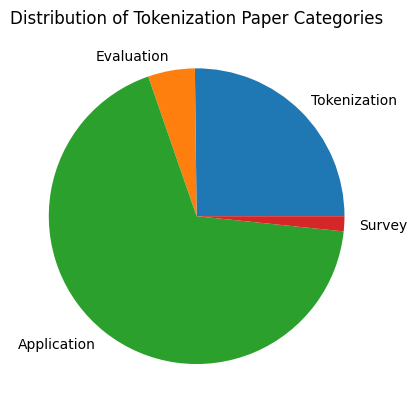

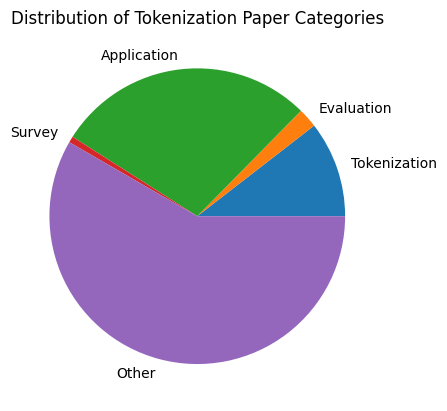

In [43]:
category_counts = {
    'Tokenization': real_tokenization['tokenization'].sum(),
    'Evaluation': real_tokenization['evaluation'].sum(),
    'Application': real_tokenization['application'].sum(),
    'Survey': real_tokenization['survey'].sum()
}
plt.figure()
plt.pie(category_counts.values(), labels=category_counts.keys())
plt.title('Distribution of Tokenization Paper Categories')
plt.show()

category_counts['Other'] = (df['topic'] == False).sum()
plt.figure()
plt.pie(category_counts.values(), labels=category_counts.keys())
plt.title('Distribution of Tokenization Paper Categories')
plt.show()

In [ ]:
# Topic 3401
# Tokenization 875
# Evaluation 178
# Application 2364 (1 missing pdf)
# Survey 57

NameError: name 'category_counts' is not defined

## Mark papers with errors and split the dataset

Errors can be pdf no longer available, missing pdf (1 case), pdf encoded as image or not text extracted.
We decide an arbitrary threshold on the Markdown file size (5kb) to filter out papers with no text extracted. This excludes 9 papers, however, papers with small size are often not relevant or are just extended abstracts.

In [41]:
import paper_dataset
import pandas as pd
import os
import tqdm

In [17]:
import importlib
importlib.reload(paper_dataset)

<module 'paper_dataset' from '/lnet/work/people/vico/TokSurvey/paper_dataset.py'>

In [42]:
ds = paper_dataset.load('data/tokenization_papers_with_category.jsonl')
missing = pd.read_csv('data/missing.csv').replace({pd.NA: ''})
tokenization = ds[ds['topic'] == True]
tokenization.shape

(3401, 19)

In [43]:
missing_urls = set(missing['pdf_url'].tolist())
print('Missing:', len(missing_urls))

Missing: 74


In [44]:
def too_small(x, threshold=5_000, root='data/pdfs/'):
    md = os.path.join(root, paper_dataset.pdf_url_to_file(x) + '.md')
    return (not os.path.exists(md)) or (os.path.getsize(md) < threshold)

In [45]:
tokenization['exclude'] = tokenization['pdf_url'].apply(lambda x: x == '' or x in missing_urls or too_small(x))
ds['exclude'] = tokenization['exclude']
tokenization

/tmp/ipykernel_3669224/3857708177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokenization['exclude'] = tokenization['pdf_url'].apply(lambda x: x == '' or x in missing_urls or too_small(x))


,bibtex_id,title,author,year,abstract,type,url,pdf_url,volume,tldr,keywords,research_area,venue,topic,tokenization,evaluation,application,survey,exclude
35,hossain-etal-2025-enhancing,Enhancing Dialectal {A}rabic Intent Detection ...,"Hossain, Shehenaz and Shammary, Fouad and Sham...",2025,Addressing the challenges of Arabic intent det...,acl,https://aclanthology.org/2025.wacl-1.5/,https://aclanthology.org/2025.wacl-1.5.pdf,Proceedings of the 4th Workshop on Arabic Corp...,None,None,None,None,1.0,0.0,0.0,1.0,0.0,False
53,coats-etal-2025-regional,Regional Distribution of the /el/-/{\ae}l/ Mer...,"Coats, Steven and Diskin-Holdaway, Chlo{\'e} a...",2025,Prelateral merger of /e/ and /{\ae}/ is a sali...,acl,https://aclanthology.org/2025.vardial-1.11/,https://aclanthology.org/2025.vardial-1.11.pdf,Proceedings of the 12th Workshop on NLP for Si...,None,None,None,None,1.0,0.0,0.0,1.0,0.0,False
99,nguyen-etal-2025-spirit,{S}pi{R}it-{LM}: Interleaved Spoken and Writte...,"Nguyen, Tu Anh and Muller, Benjamin and Yu, Bo...",2025,"We introduce SpiRit-LM, a foundation multimoda...",acl,https://aclanthology.org/2025.tacl-1.2/,https://aclanthology.org/2025.tacl-1.2.pdf,Transactions of the Association for Computatio...,None,None,None,None,1.0,0.0,0.0,1.0,0.0,False
111,nozaki-etal-2025-vrcp,{VRCP}: Vocabulary Replacement Continued Pretr...,"Nozaki, Yuta and Nakashima, Dai and Sato, Ryo ...",2025,Building large language models (LLMs) for non-...,acl,https://aclanthology.org/2025.sumeval-2.5/,https://aclanthology.org/2025.sumeval-2.5.pdf,Proceedings of the Second Workshop on Scaling ...,None,None,None,None,1.0,1.0,0.0,0.0,0.0,False
122,kamajaya-moeljadi-2025-indomorph,{I}ndo{M}orph: a Morphology Engine for {I}ndon...,"Kamajaya, Ian and Moeljadi, David",2025,Indonesian is an agglutinative language and ri...,acl,https://aclanthology.org/2025.sealp-1.7/,https://aclanthology.org/2025.sealp-1.7.pdf,Proceedings of the Second Workshop in South Ea...,None,None,None,None,1.0,0.0,0.0,1.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149324,u2vAyMeLMm_liu2024infinigram,Infini-gram: Scaling Unbounded n-gram Language...,Jiacheng Liu and Sewon Min and Luke Zettlemoye...,2024,Are $n$-gram language models still relevant in...,colm,https://openreview.net/forum?id=u2vAyMeLMm,https://openreview.net/pdf/b6c910d9f431718c212...,First Conference on Language Modeling,We built the largest ever n-gram LM on trillio...,"infini-gram,n-gram,language model,suffix array","Data, Science of LMs, Compute efficient LMs, E...",COLM,1.0,0.0,0.0,1.0,0.0,False
149343,dWYRjT501w_bronzini2024unveiling,Unveiling LLMs: The Evolution of Latent Repres...,Marco Bronzini and Carlo Nicolini and Bruno Le...,2024,Large Language Models (LLMs) demonstrate an im...,colm,https://openreview.net/forum?id=dWYRjT501w,https://openreview.net/pdf/bf7d682e4b3be43bc58...,First Conference on Language Modeling,A framework based on the technique of activati...,"Large Language Models, Latent Representations,...","Science of LMs, LMs and the world",COLM,1.0,0.0,0.0,1.0,0.0,False
149348,xWYRL1eR74_williams2024fuseing,FUSE-ing Language Models: Zero-Shot Adapter Di...,Joshua Nathaniel Williams and J Zico Kolter,2024,The widespread use of large language models ha...,colm,https://openreview.net/forum?id=xWYRL1eR74,https://openreview.net/pdf/f513b4d92d7c85b0b9b...,First Conference on Language Modeling,We propose a method for computing gradients th...,"prompt optimization, zero-shot methods, prompt...","Alignment, LMs and the world, LMs on diverse m...",COLM,1.0,1.0,0.0,0.0,0.0,False
149353,wi9IffRhVM_wang2024guiding,Guiding Language Model Reasoning with Planning...,Xinyi Wang and Lucas Caccia and Oleksiy Ostape...,2024,Large language models (LLMs) have recently att...,colm,https://openreview.net/forum?id=wi9IffRhVM,https://openreview.net/pdf/67aeb1e900f70b3854d...,First Conference on Language Modeling,We propose to add specialized planning tokens ...,"chain-of-thought reason

In [46]:
ds.to_json('data/tokenization_papers_with_category.jsonl', orient='records', lines=True)
tokenization.to_json('data/selected_tokenization_papers.jsonl', orient='records', lines=True)

In [11]:
tokenization[tokenization['author'].apply(lambda x: x is not None and 'kudo' in x.lower())]

,bibtex_id,title,author,year,abstract,type,url,pdf_url,volume,tldr,keywords,research_area,venue,topic,tokenization,evaluation,application,survey,exclude
1957,kamoda-etal-2025-weight,Weight-based Analysis of Detokenization in Lan...,"Kamoda, Go and Heinzerling, Benjamin and Inaba...",2025,According to the stages-of-inference hypothesi...,acl,https://aclanthology.org/2025.findings-naacl.355/,https://aclanthology.org/2025.findings-naacl.3...,Findings of the Association for Computational ...,None,None,None,None,1.0,0.0,0.0,1.0,0.0,False
52685,kudo-2018-subword,Subword Regularization: Improving Neural Netwo...,"Kudo, Taku",2018,Subword units are an effective way to alleviat...,acl,https://aclanthology.org/P18-1007/,https://aclanthology.org/P18-1007.pdf,Proceedings of the 56th Annual Meeting of the ...,None,None,None,None,1.0,1.0,0.0,0.0,0.0,False
54964,kudo-richardson-2018-sentencepiece,{S}entence{P}iece: A simple and language indep...,"Kudo, Taku and Richardson, John",2018,"This paper describes SentencePiece, a language...",acl,https://aclanthology.org/D18-2012/,https://aclanthology.org/D18-2012.pdf,Proceedings of the 2018 Conference on Empirica...,None,None,None,None,1.0,1.0,0.0,0.0,0.0,False


## Evaluation papers

- Papers over the years
- LLM: languages, motivation
- github / usable github


In [1]:
import importlib
import llm_filter
import pandas as pd
import paper_dataset
import tqdm
import iso639
import json
tqdm.tqdm.pandas()

/home/vico/personal_work_ms/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 09-29 15:32:57 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 09-29 15:32:59 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [2]:
evaluation = pd.read_json('data/selected_tokenization_papers.jsonl', lines=True)
evaluation = evaluation[(evaluation['exclude'] == False) & (evaluation['evaluation'] == True)]
evaluation.shape

(173, 21)

In [16]:
def exclusive_english(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_EN, {'title': title, 'content': md}, local=True)
    return answer.lower().strip().startswith("yes")

def languages(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_MULTILINGUAL, {'title': title, 'content': md}, local=True, max_tokens=256)
    langs = llm_filter.extract_languages(answer)
    return langs, answer

In [2]:
# evaluation['exclusive_english'] = evaluation.progress_apply(exclusive_english, axis=1)
# all_answers = []
# all_langs = []
# for item in tqdm.tqdm(evaluation.iloc):
#     codes, answer = languages(item)
#     all_answers.append(answer)
#     all_langs.append(codes)
# with open('evaluation_language_answer.json', 'wt') as f:
#     json.dump(all_answers, f)

# evaluation['languages'] = all_langs
# evaluation.to_json('data/evaluation_papers.jsonl', orient='records', lines=True)
evaluation = pd.read_json('data/evaluation_papers.jsonl', lines=True)

In [20]:
no_lang = evaluation[evaluation['languages'].apply(lambda x: len(x) == 0)]
for i in no_lang['title']:
    print(i)
    print('-'*20)

The Impact of Word Splitting on the Semantic Content of Contextualized Word Representations
--------------------
Evaluating Text-to-Speech Synthesis from a Large Discrete Token-based Speech Language Model
--------------------
Training and Domain Adaptation for Supervised Text Segmentation
--------------------
{R}ethink{CWS}: Is {C}hinese Word Segmentation a Solved Task?
--------------------
How to account for mispellings: Quantifying the benefit of character representations in neural content scoring models
--------------------
Large Language Models Lack Understanding of Character Composition of Words
--------------------
Protein Structure Tokenization: Benchmarking and New Recipe
--------------------


In [3]:
import matplotlib.pyplot as plt

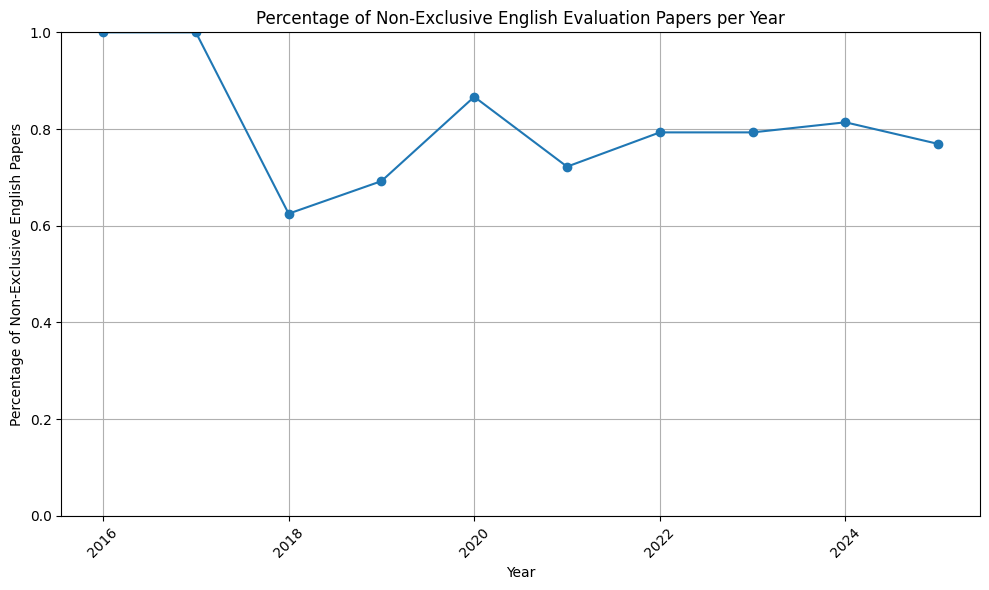

In [23]:
# Plot the number of papers that have 'exclusive_english' == False over the years, normalize by the total number of papers per year
years = sorted(evaluation['year'].unique())
exclusive_counts = []
total_counts = []       
for year in years:
    year_data = evaluation[evaluation['year'] == year]
    exclusive_count = year_data[year_data['exclusive_english'] == False].shape[0]
    total_count = year_data.shape[0]
    exclusive_counts.append(exclusive_count)
    total_counts.append(total_count)
plt.figure(figsize=(10, 6))
plt.plot(years, [e / t if t > 0 else 0 for e, t in zip(exclusive_counts, total_counts)], marker='o')
plt.title('Percentage of Non-Exclusive English Evaluation Papers per Year')
plt.xlabel('Year')
plt.ylabel('Percentage of Non-Exclusive English Papers')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

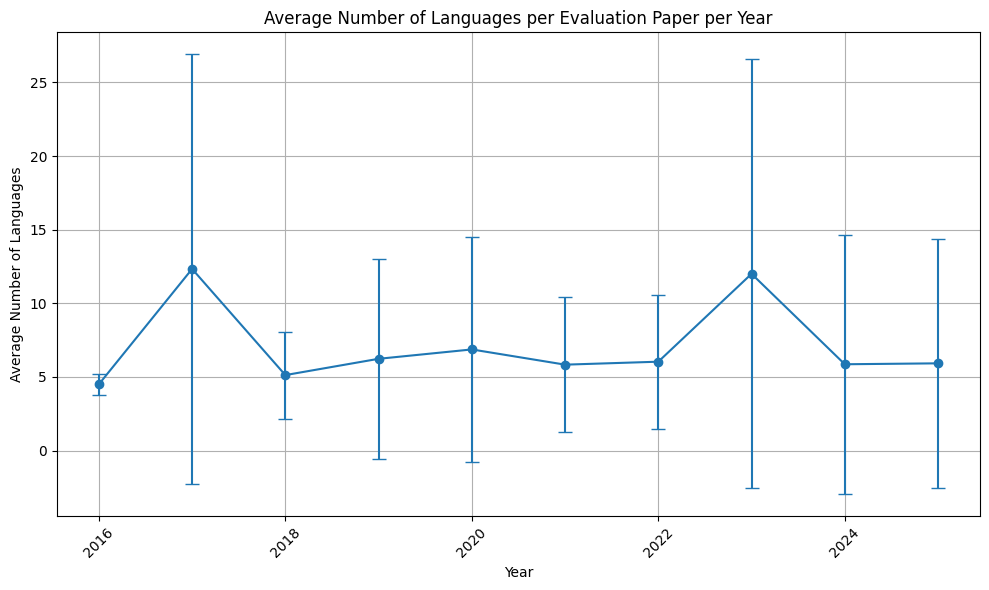

In [ ]:
years = sorted(evaluation['year'].unique())
avg_lang_counts = []
std_lang_counts = []
for year in years:
    year_data = evaluation[evaluation['year'] == year]
    lang_lens = year_data['languages'].apply(len)
    avg_lang_count = lang_lens.mean()
    std_lang_count = lang_lens.std()
    avg_lang_counts.append(avg_lang_count)
    std_lang_counts.append(std_lang_count)

plt.figure(figsize=(10, 6))
plt.errorbar(years, avg_lang_counts, yerr=std_lang_counts, fmt='o-', capsize=5)
plt.title('Average Number of Languages per Evaluation Paper per Year')
plt.xlabel('Year')
plt.ylabel('Average Number of Languages')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

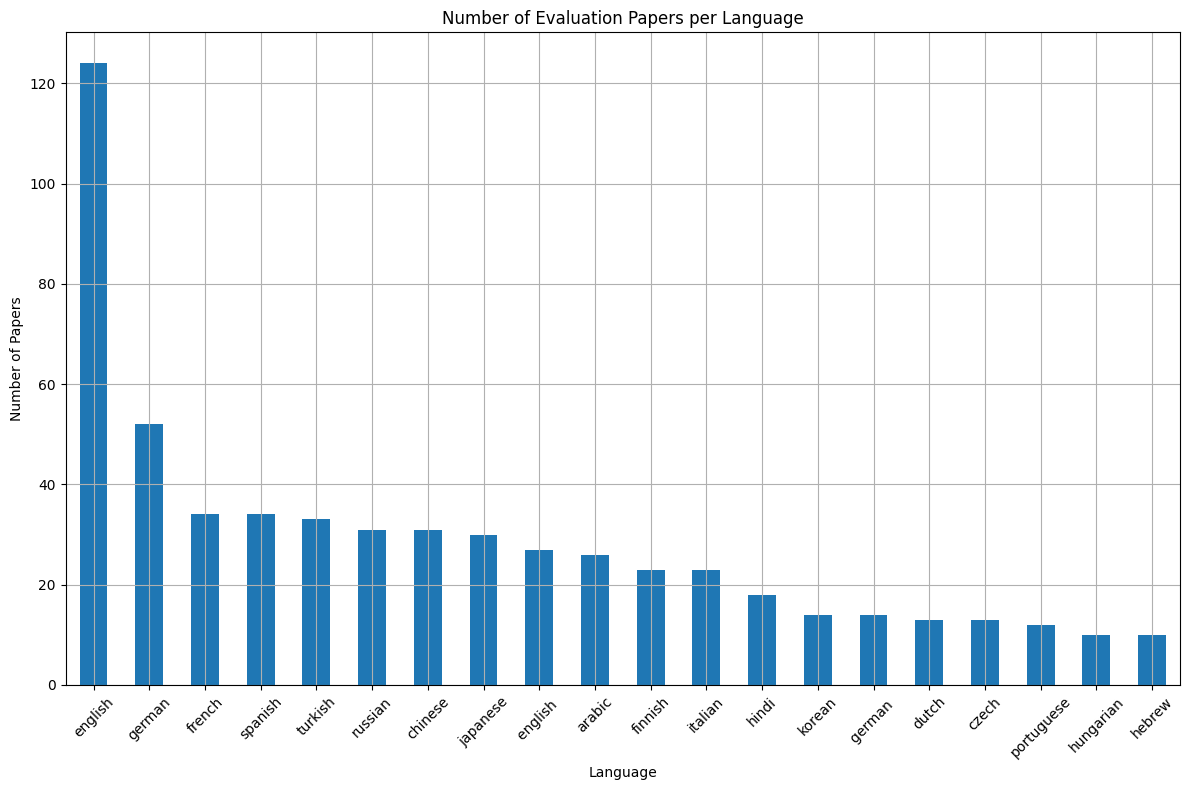

In [32]:
# PLot histogram of the number of papers per language
all_langs = [lang for sublist in evaluation['languages'].tolist() for lang in sublist]
all_langs = pd.Series(all_langs).value_counts()
top_lang_counts = all_langs.head(20)
plt.figure(figsize=(12, 8))
top_lang_counts.plot(kind='bar')
plt.title('Number of Evaluation Papers per Language')
plt.xlabel('Language')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

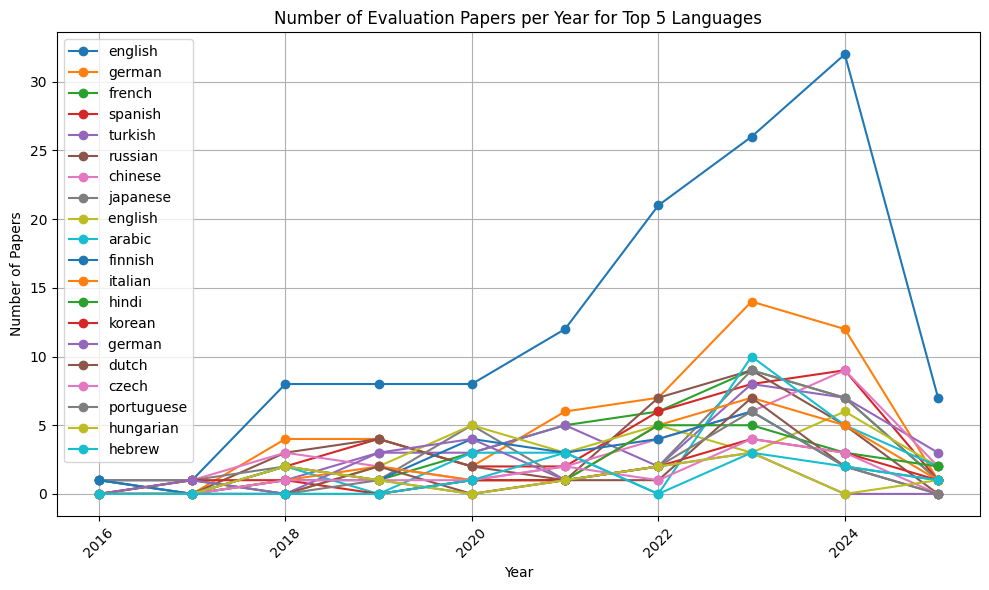

In [7]:
# Plot the number of papers over the years for the top 5 languages
years = sorted(evaluation['year'].unique())
all_langs = [lang for sublist in evaluation['languages'].tolist() for lang in sublist]
all_langs = pd.Series(all_langs).value_counts()
top_languages = all_langs.head(20).index.tolist()
plt.figure(figsize=(10, 6))
for lang in top_languages:
    lang_counts = []
    for year in years:
        year_data = evaluation[evaluation['year'] == year]
        count = year_data[year_data['languages'].apply(lambda x: lang in x)].shape[0]
        lang_counts.append(count)
    plt.plot(years, lang_counts, marker='o', label=lang)
plt.title('Number of Evaluation Papers per Year for Top 5 Languages')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Add the other fields

- Based on BPE/Unigram/WordPiece/PIXEL/Tokenizer-free/Other
- Units: subword/morphemes/characters/bytes/pixels/other
- Evaluation metrics
- Multilingual
- Languages
- Motivation